In [3]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
# Ensure font persists across disconnects: keep the .ttf on Drive, copy to /content each session
DRIVE_FONT_PATH = "/content/drive/MyDrive/lab_assets/times.ttf"  # adjust to your actual Drive path
font_path = "/content/times.ttf"

if not os.path.exists(font_path):
    if os.path.exists(DRIVE_FONT_PATH):
        import shutil
        shutil.copy(DRIVE_FONT_PATH, font_path)
    else:
        raise FileNotFoundError(
            "times.ttf not found on Drive or /content. Upload it once to Drive at "
            f"{DRIVE_FONT_PATH} so it survives runtime disconnects."
        )

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded Font:", font_name)

mpl.rcParams['font.family'] = font_name
mpl.rcParams['font.size'] = 16
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16

def save_eps_or_pdf(filename, dpi=600, max_size_kb=100):
    eps_name = filename + ".eps"
    plt.savefig(eps_name, format='eps', dpi=dpi, bbox_inches='tight')
    size_kb = os.path.getsize(eps_name) / 1024

    if size_kb > max_size_kb:
        os.remove(eps_name)
        pdf_name = filename + ".pdf"
        plt.savefig(pdf_name, format='pdf', bbox_inches='tight')
        print(f"{pdf_name} saved (EPS was {size_kb:.1f} KB)")
    else:
        print(f"{eps_name} saved ({size_kb:.1f} KB)")

Loaded Font: Times New Roman


In [ ]:
!pip install --upgrade protobuf

# Restart runtime programmatically so changes take effect
import os
os._exit(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 24.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.


In [5]:
!pip install -q importlib_resources

In [2]:
import os, json, gc, time, pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers, regularizers
import tensorflow_datasets as tfds
from google.colab import drive

# Mount Drive & setup output folders
drive.mount('/content/drive')
RESULTS_DIR = "/content/drive/MyDrive/lab_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/models", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/histories", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/plots", exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE_DEFAULT = 32
NUM_CLASSES = 37
SEED = 42

(ds_train_full, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    with_info=True,
    as_supervised=True,
)

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

ds_train_full = ds_train_full.shuffle(3680, seed=SEED)
n_val = int(3680 * 0.15)

ds_val_raw = ds_train_full.take(n_val)
ds_train_raw = ds_train_full.skip(n_val)

def make_pipeline(ds_raw, batch_size, shuffle=False):
    ds = ds_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Helper function to plot & save directly from Drive histories
def plot_and_save(history_keys, title, filename):
    plt.figure(figsize=(10, 4))

    # Subplot 1: Validation Accuracy
    plt.subplot(1, 2, 1)
    for key in history_keys:
        path = f"{RESULTS_DIR}/histories/{key}.json"
        if os.path.exists(path):
            with open(path, "r") as f:
                data = json.load(f)
            plt.plot(data['val_accuracy'], label=key)
    plt.title(f"{title} - Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Subplot 2: Validation Loss
    plt.subplot(1, 2, 2)
    for key in history_keys:
        path = f"{RESULTS_DIR}/histories/{key}.json"
        if os.path.exists(path):
            with open(path, "r") as f:
                data = json.load(f)
            plt.plot(data['val_loss'], label=key)
    plt.title(f"{title} - Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/plots/{filename}.eps", format='eps')
    plt.savefig(f"{RESULTS_DIR}/plots/{filename}.png")
    plt.show()

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.QXKNXA_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.QXKNXA_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Setup complete.


In [ ]:
def build_model(init='glorot_uniform', dropout_rate=0.0, l2_lambda=0.0, use_bn_head=True, base_trainable=False):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=init,
                      kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                            kernel_initializer=init,
                            kernel_regularizer=reg)(x)
    model = models.Model(inputs, outputs)
    return model

def run_experiment(name, model, train_ds, val_ds, epochs=8, optimizer='adam', lr=1e-3):
    if optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate=lr)
    elif optimizer == 'momentum':
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    hist_dict = history.history
    hist_dict['train_time_sec'] = elapsed
    hist_dict['num_params'] = model.count_params()

    with open(f"{RESULTS_DIR}/histories/{name}.json", "w") as f:
        json.dump(hist_dict, f)

    model.save(f"{RESULTS_DIR}/models/{name}.keras")

    print(f"[{name}] done in {elapsed:.1f}s, final val_acc={hist_dict['val_accuracy'][-1]:.4f}")

    # free memory
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return hist_dict

# ---- Weight Initialization runs ----
init_batch_size = 32
train_ds_b1 = make_pipeline(ds_train_raw, init_batch_size, shuffle=True)
val_ds_b1 = make_pipeline(ds_val_raw, init_batch_size)

initializers_to_test = {
    "zeros": "zeros",
    "random_normal": "random_normal",
    "xavier": "glorot_uniform",
    "he": "he_normal",
}

for name, init in initializers_to_test.items():
    print(f"\n=== Training with {name} initialization ===")
    m = build_model(init=init)
    run_experiment(f"init_{name}", m, train_ds_b1, val_ds_b1, epochs=8, optimizer='adam')


=== Training with zeros initialization ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 425ms/step - accuracy: 0.0205 - loss: 3.6114 - val_accuracy: 0.0272 - val_loss: 3.6111
Epoch 2/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.0253 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6112
Epoch 3/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.0240 - loss: 3.6110 - val_accuracy: 0.0272 - val_loss: 3.6111
Epoch 4/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0272 - loss: 3.6110 - val_accuracy: 0.0272 - val_loss: 3.6113
Epoch 5/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0243 - loss: 3.6109 - val_accuracy: 0.0272 - val_loss: 3.6113
Epoch 6/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.0294 - loss: 3.6108 - val_accuracy: 0.0272 - val_loss: 3.6114
Epoch 7/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.0259 - loss: 3.6108 - val_accuracy: 0.0272 - val_loss: 3.6115
Epoch 8/8
98/98 ━━━━━━━

/content/drive/MyDrive/lab_results/plots/plot1_init_train_loss_and_val_acc.eps saved (62.9 KB)


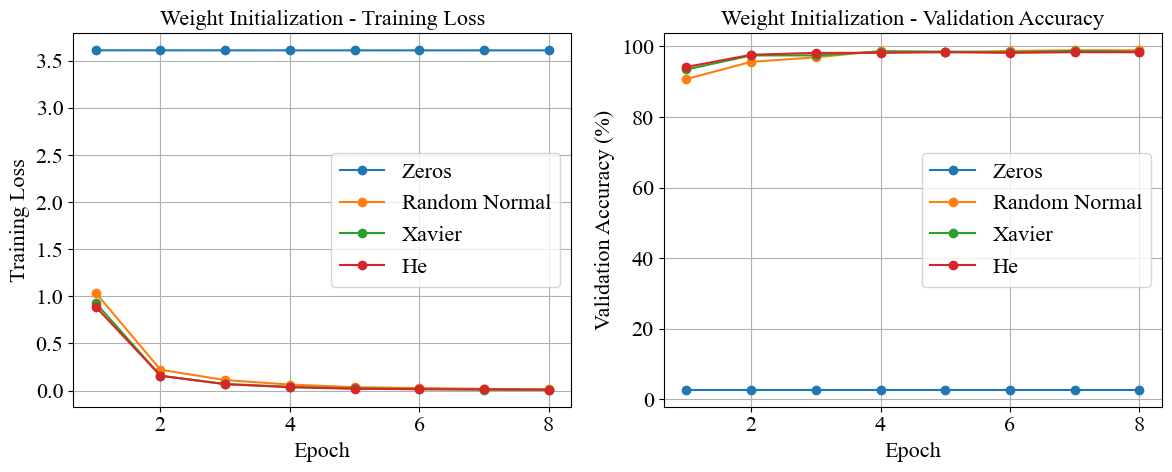

Plots saved to Drive:
- /content/drive/MyDrive/lab_results/plots/plot1_init_train_loss_and_val_acc.png


In [ ]:
# ============================================================
# BLOCK 1b (corrected) — Plot 1: Training Loss, Plot 2: Val Accuracy
# ============================================================

import os, json
import matplotlib.pyplot as plt

init_keys = {
    "Zeros": "init_zeros",
    "Random Normal": "init_random_normal",
    "Xavier": "init_xavier",
    "He": "init_he"
}

plt.figure(figsize=(12, 5))

# ---- Plot 1: Training Loss vs Epoch (was incorrectly plotting val_loss before) ----
plt.subplot(1, 2, 1)
for label, key in init_keys.items():
    path = f"{RESULTS_DIR}/histories/{key}.json"
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        plt.plot(range(1, len(data['loss'])+1), data['loss'], label=label, marker='o')
plt.title("Weight Initialization - Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.legend(); plt.grid(True)

# ---- Plot 2: Validation Accuracy vs Epoch (unchanged, was already correct) ----
plt.subplot(1, 2, 2)
for label, key in init_keys.items():
    path = f"{RESULTS_DIR}/histories/{key}.json"
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        plt.plot(range(1, len(data['val_accuracy'])+1),
                  [a*100 for a in data['val_accuracy']], label=label, marker='o')
plt.title("Weight Initialization - Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plots/plot1_init_train_loss_and_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot1_init_train_loss_and_val_acc")
plt.show()

print("Plots saved to Drive:")
print(f"- {RESULTS_DIR}/plots/plot1_init_train_loss_and_val_acc.png")

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Name: ", tf.test.gpu_device_name())

Num GPUs Available:  1
GPU Name:  /device:GPU:0



=== Training with no_reg ===
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 263ms/step - accuracy: 0.7267 - loss: 1.0093 - val_accuracy: 0.9330 - val_loss: 0.2437
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9357 - loss: 0.2184 - val_accuracy: 0.9746 - val_loss: 0.1394
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9751 - loss: 0.1066 - val_accuracy: 0.9801 - val_loss: 0.0882
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9895 - loss: 0.0580 - val_accuracy: 0.9909 - val_loss: 0.0532
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9965 - loss: 0.0331 - val_accuracy: 0.9891 - val_loss: 0.0494
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9994 - loss: 0.0206 - val_accuracy: 0.9909 - val_loss: 0.0419
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9997 - loss: 0.0142 - val_accuracy: 0.9909 - val_loss: 0.0372
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 1.0000 - loss: 0

NameError: name 'save_eps_or_pdf' is not defined

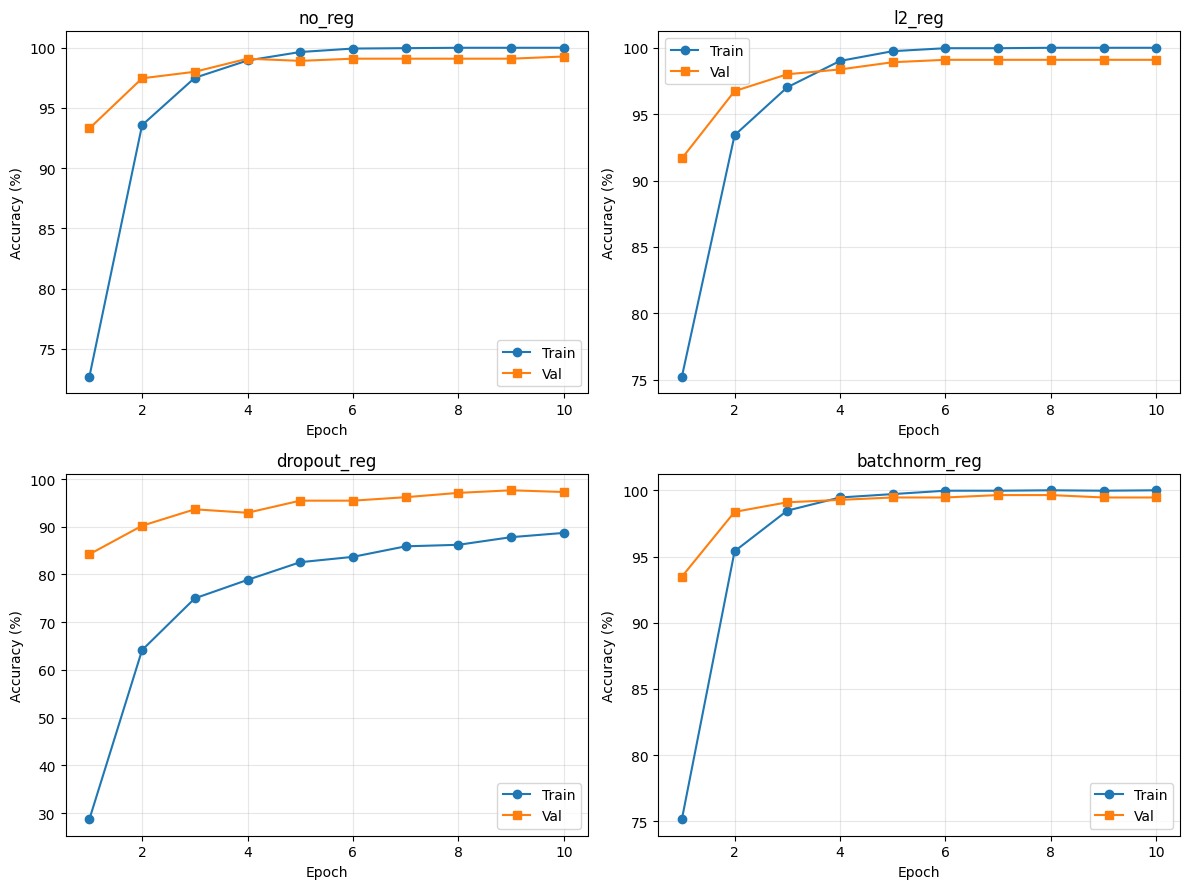

In [ ]:
# ============================================================
# BLOCK 2 — Regularization, Overfitting, Batch Normalization
# ============================================================

def build_model_b2(init='he_normal', dropout_rate=0.0, l2_lambda=0.0, use_bn_head=True, base_trainable=False):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=init,
                      kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                            kernel_initializer=init,
                            kernel_regularizer=reg)(x)
    return models.Model(inputs, outputs)


def run_experiment_b2(name, model, train_ds, val_ds, epochs=10, optimizer='adam', lr=1e-3):
    hist_path = f"{RESULTS_DIR}/histories/{name}.json"

    if os.path.exists(hist_path):
        print(f"[{name}] history found on Drive — skipping training.")
        with open(hist_path) as f:
            return json.load(f)

    if optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate=lr)
    elif optimizer == 'momentum':
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    hist_dict = history.history
    hist_dict['train_time_sec'] = elapsed
    hist_dict['num_params'] = model.count_params()

    with open(hist_path, "w") as f:
        json.dump(hist_dict, f)

    model.save(f"{RESULTS_DIR}/models/{name}.keras")
    print(f"[{name}] done in {elapsed:.1f}s, final val_acc={hist_dict['val_accuracy'][-1]:.4f}")

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return hist_dict


# ---- Pipelines ----
train_ds_b2 = make_pipeline(ds_train_raw, 32, shuffle=True)
val_ds_b2   = make_pipeline(ds_val_raw, 32)

# ---- Configs: no_reg / l2_reg / dropout_reg / batchnorm_reg ----
reg_configs = {
    "no_reg":        dict(dropout_rate=0.0, l2_lambda=0.0,  use_bn_head=False),
    "l2_reg":        dict(dropout_rate=0.0, l2_lambda=1e-4, use_bn_head=False),
    "dropout_reg":   dict(dropout_rate=0.5, l2_lambda=0.0,  use_bn_head=False),
    "batchnorm_reg": dict(dropout_rate=0.0, l2_lambda=0.0,  use_bn_head=True),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Training with {name} ===")
    hist_path = f"{RESULTS_DIR}/histories/reg_{name}.json"
    if os.path.exists(hist_path):
        reg_histories[name] = run_experiment_b2(f"reg_{name}", None, None, None)  # will hit cache branch, model unused
    else:
        m = build_model_b2(init="he_normal", **cfg)
        reg_histories[name] = run_experiment_b2(f"reg_{name}", m, train_ds_b2, val_ds_b2, epochs=10, optimizer='adam')


/content/drive/MyDrive/lab_results/plots/plot3_reg_train_val_acc.eps saved (64.3 KB)


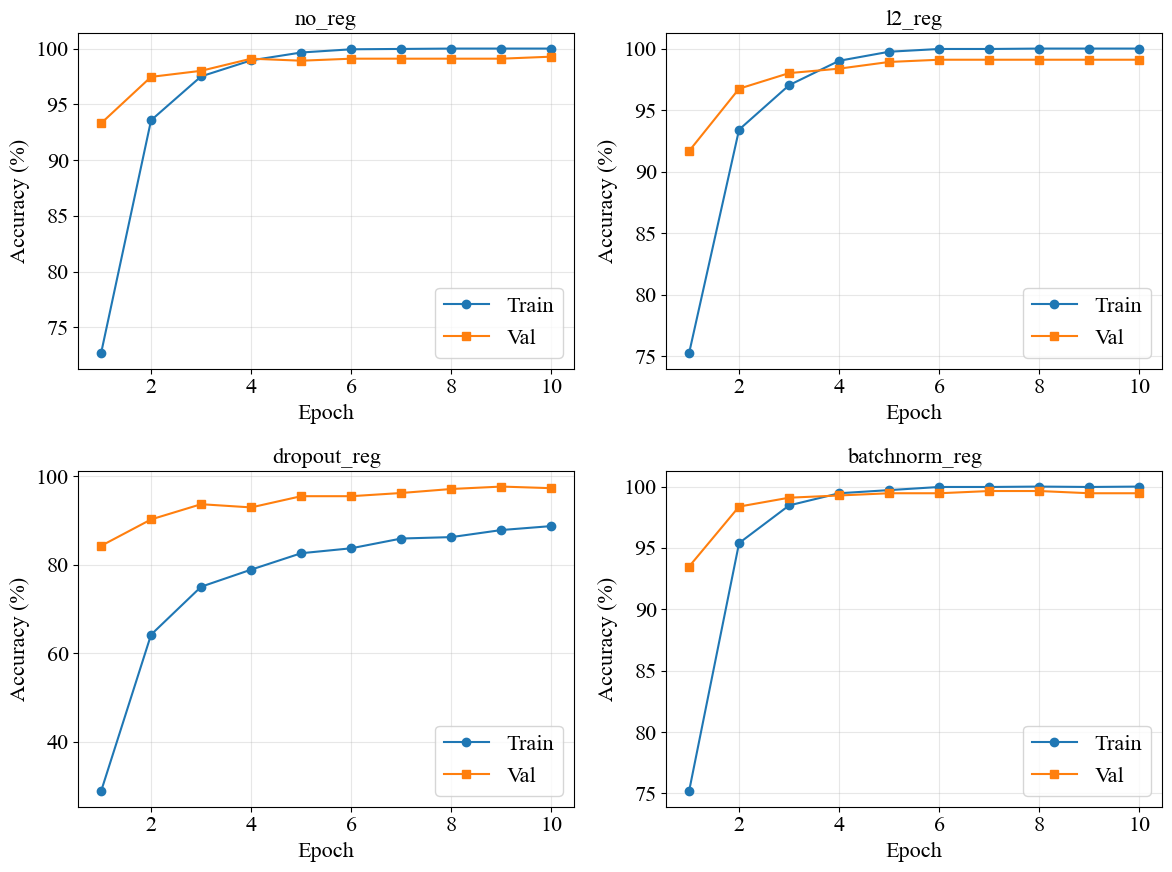

/content/drive/MyDrive/lab_results/plots/plot4_reg_train_val_loss.eps saved (61.7 KB)


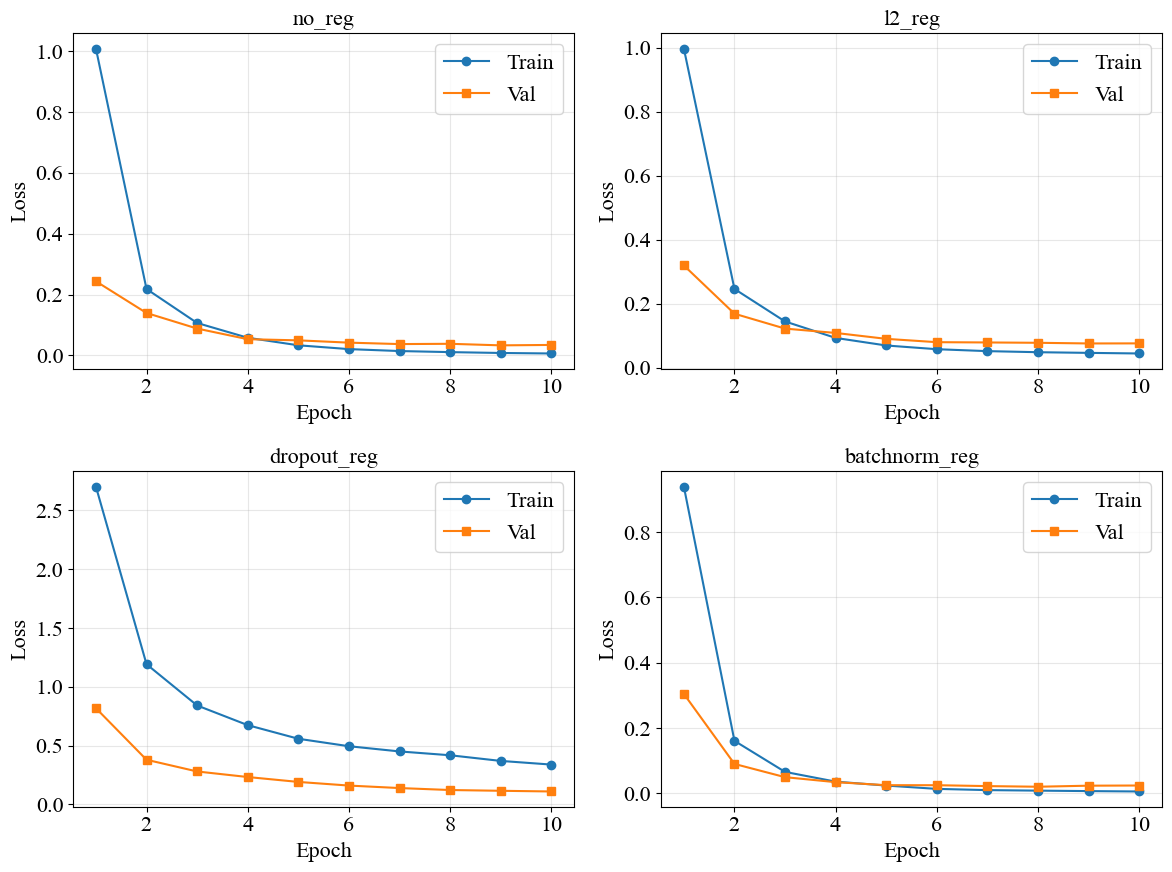

/content/drive/MyDrive/lab_results/plots/plot5_bn_comparison.eps saved (37.4 KB)


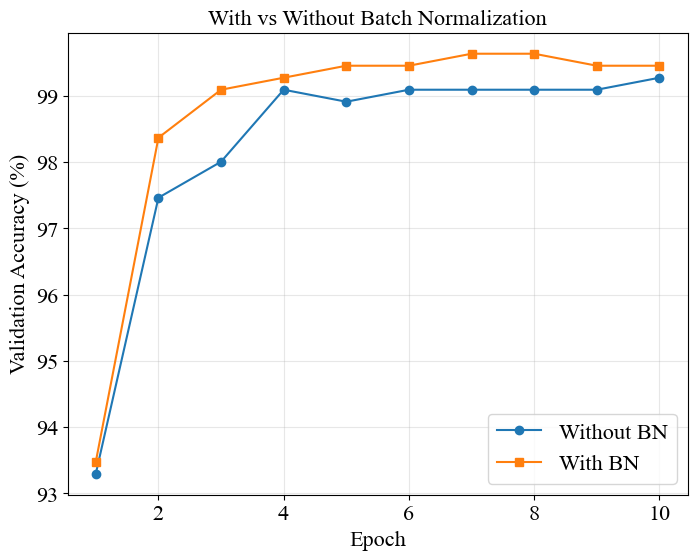

In [ ]:

# ---- Plot 3: Train vs Val Accuracy per config (generalization gap) ----
fig, axes = plt.subplots(2, 2, figsize=(12,9))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    ep = range(1, len(h['accuracy'])+1)
    ax.plot(ep, [a*100 for a in h['accuracy']], label='Train', marker='o')
    ax.plot(ep, [a*100 for a in h['val_accuracy']], label='Val', marker='s')
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plots/plot3_reg_train_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot3_reg_train_val_acc")
plt.show()

# ---- Plot 4: Train vs Val Loss per config ----
fig, axes = plt.subplots(2, 2, figsize=(12,9))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    ep = range(1, len(h['loss'])+1)
    ax.plot(ep, h['loss'], label='Train', marker='o')
    ax.plot(ep, h['val_loss'], label='Val', marker='s')
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plots/plot4_reg_train_val_loss.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot4_reg_train_val_loss")
plt.show()

# ---- Plot 5: With vs Without BN (reuses no_reg / batchnorm_reg — no extra training) ----
plt.figure(figsize=(8,6))
plt.plot(range(1, len(reg_histories['no_reg']['val_accuracy'])+1),
         [a*100 for a in reg_histories['no_reg']['val_accuracy']], label='Without BN', marker='o')
plt.plot(range(1, len(reg_histories['batchnorm_reg']['val_accuracy'])+1),
         [a*100 for a in reg_histories['batchnorm_reg']['val_accuracy']], label='With BN', marker='s')
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("With vs Without Batch Normalization")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot5_bn_comparison.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot5_bn_comparison")
plt.show()

In [ ]:
# ============================================================
# BLOCK 3a — Optimizers: Training
# ============================================================

def build_model_b3(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True, base_trainable=False):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=init,
                      kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                            kernel_initializer=init,
                            kernel_regularizer=reg)(x)
    return models.Model(inputs, outputs)


def run_experiment_b3(name, model, train_ds, val_ds, epochs=10, optimizer='adam', lr=1e-3):
    hist_path = f"{RESULTS_DIR}/histories/{name}.json"

    if os.path.exists(hist_path):
        print(f"[{name}] history found on Drive — skipping training.")
        with open(hist_path) as f:
            return json.load(f)

    if optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate=lr)
    elif optimizer == 'momentum':
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    hist_dict = history.history
    hist_dict['train_time_sec'] = elapsed
    hist_dict['num_params'] = model.count_params()

    with open(hist_path, "w") as f:
        json.dump(hist_dict, f)

    model.save(f"{RESULTS_DIR}/models/{name}.keras")
    print(f"[{name}] done in {elapsed:.1f}s, final val_acc={hist_dict['val_accuracy'][-1]:.4f}")

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return hist_dict


# ---- Pipelines ----
train_ds_b3 = make_pipeline(ds_train_raw, 32, shuffle=True)
val_ds_b3   = make_pipeline(ds_val_raw, 32)

# ---- Train all 4 optimizers ----
optimizer_configs = ["sgd", "momentum", "rmsprop", "adam"]

optim_histories = {}
for opt_name in optimizer_configs:
    print(f"\n=== Optimizer: {opt_name} ===")
    m = build_model_b3(init="he_normal", dropout_rate=0.3, use_bn_head=True)
    optim_histories[opt_name] = run_experiment_b3(
        f"optim_{opt_name}", m, train_ds_b3, val_ds_b3, epochs=10, optimizer=opt_name
    )

print("\nBlock 3a complete — all optimizer histories saved to Drive.")


=== Optimizer: sgd ===
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.0390 - loss: 4.9351 - val_accuracy: 0.1033 - val_loss: 3.3599
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.0828 - loss: 4.2068 - val_accuracy: 0.2391 - val_loss: 2.8625
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1423 - loss: 3.6309 - val_accuracy: 0.3804 - val_loss: 2.3639
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2132 - loss: 3.1171 - val_accuracy: 0.5145 - val_loss: 1.9489
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2852 - loss: 2.7402 - val_accuracy: 0.5996 - val_loss: 1.6239
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.3462 - loss: 2.4087 - val_accuracy: 0.6649 - val_loss: 1.3773
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4038 - loss: 2.1359 - val_accuracy: 0.7120 - val_loss: 1.1886
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4383 - loss: 2.0026 

/content/drive/MyDrive/lab_results/plots/plot6_optim_train_loss.eps saved (37.0 KB)


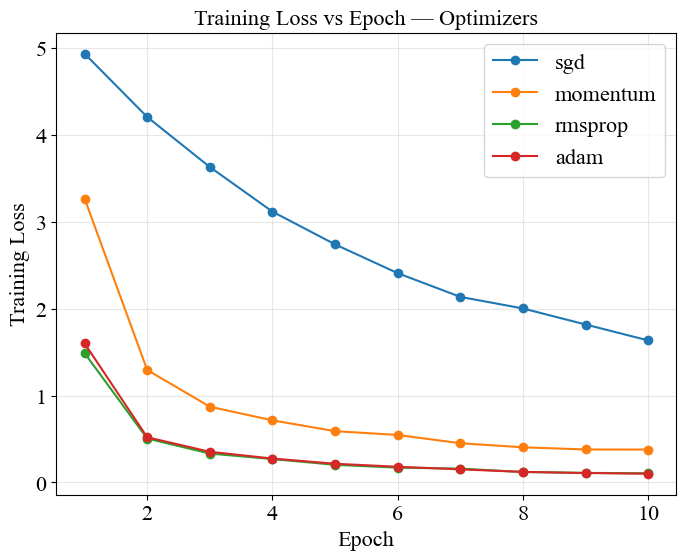

/content/drive/MyDrive/lab_results/plots/plot7_optim_val_acc.eps saved (39.1 KB)


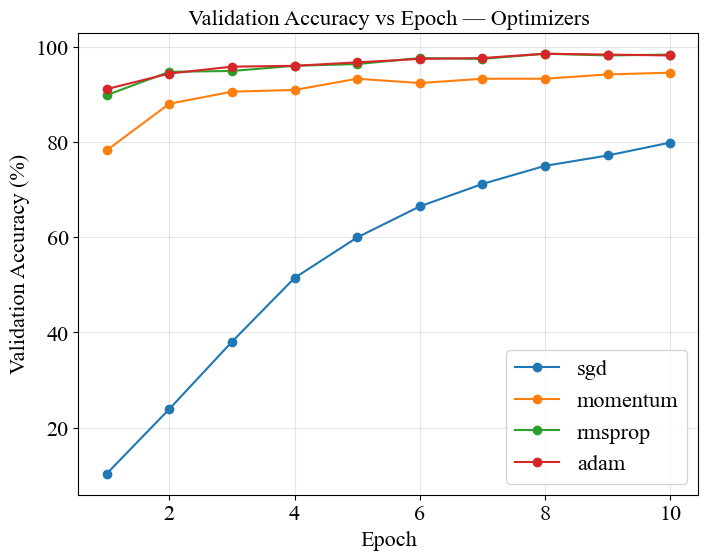

NameError: name 'pd' is not defined

In [ ]:
# ============================================================
# BLOCK 3b — Optimizers: Plotting (reads histories from Drive)
# ============================================================

optimizer_configs = ["sgd", "momentum", "rmsprop", "adam"]

optim_histories = {}
for opt_name in optimizer_configs:
    path = f"{RESULTS_DIR}/histories/optim_{opt_name}.json"
    with open(path) as f:
        optim_histories[opt_name] = json.load(f)

# ---- Plot 6: Training Loss vs Epoch ----
plt.figure(figsize=(8,6))
for opt_name in optimizer_configs:
    h = optim_histories[opt_name]
    plt.plot(range(1, len(h['loss'])+1), h['loss'], label=opt_name, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch — Optimizers")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot6_optim_train_loss.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot6_optim_train_loss")
plt.show()

# ---- Plot 7: Validation Accuracy vs Epoch ----
plt.figure(figsize=(8,6))
for opt_name in optimizer_configs:
    h = optim_histories[opt_name]
    plt.plot(range(1, len(h['val_accuracy'])+1), [a*100 for a in h['val_accuracy']], label=opt_name, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Epoch — Optimizers")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot7_optim_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot7_optim_val_acc")
plt.show()

# ---- Optimizer summary table (Section 8) ----
rows = []
for opt_name in optimizer_configs:
    h = optim_histories[opt_name]
    best_val_acc = max(h['val_accuracy'])
    epoch_to_converge = h['val_accuracy'].index(best_val_acc) + 1
    rows.append({
        "Optimizer": opt_name,
        "Final Loss": round(h['loss'][-1], 4),
        "Best Val. Accuracy": round(best_val_acc*100, 2),
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(h['train_time_sec'], 1)
    })
optim_table = pd.DataFrame(rows)
optim_table.to_csv(f"{RESULTS_DIR}/histories/optim_summary_table.csv", index=False)
print(optim_table)

In [ ]:
# ============================================================
# BLOCK 4a — CNN Hyperparameter Tuning: Training
# One-hyperparameter-at-a-time sweep (Section 9)
# Base config held fixed except the parameter under test
# ============================================================

def build_model_b4(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True, base_trainable=False):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=init,
                      kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                            kernel_initializer=init,
                            kernel_regularizer=reg)(x)
    return models.Model(inputs, outputs)


def run_experiment_b4(name, model, train_ds, val_ds, epochs=8, optimizer='adam', lr=1e-3):
    hist_path = f"{RESULTS_DIR}/histories/{name}.json"

    if os.path.exists(hist_path):
        print(f"[{name}] history found on Drive — skipping training.")
        with open(hist_path) as f:
            return json.load(f)

    if optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate=lr)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    hist_dict = history.history
    hist_dict['train_time_sec'] = elapsed
    hist_dict['num_params'] = model.count_params()

    with open(hist_path, "w") as f:
        json.dump(hist_dict, f)

    model.save(f"{RESULTS_DIR}/models/{name}.keras")
    print(f"[{name}] done in {elapsed:.1f}s, final val_acc={hist_dict['val_accuracy'][-1]:.4f}")

    # aggressive cleanup — critical in this block given the number of sequential runs
    del model, history
    tf.keras.backend.clear_session()
    gc.collect()

    return hist_dict


# ---- Fixed base config (baseline: he init, dropout 0.3, BN head, adam, lr 1e-3, batch 32) ----
BASE_INIT = 'he_normal'
BASE_DROPOUT = 0.3
BASE_LR = 1e-3
BASE_BATCH = 32
BASE_OPTIMIZER = 'adam'
SWEEP_EPOCHS = 8

lr_histories = {}
batch_histories = {}
dropout_histories = {}

# ---- Sweep 1: Learning Rate (batch/dropout held at base) ----
train_ds_base = make_pipeline(ds_train_raw, BASE_BATCH, shuffle=True)
val_ds_base   = make_pipeline(ds_val_raw, BASE_BATCH)

for lr in [0.001, 0.0001]:
    name = f"hp_lr_{lr}"
    print(f"\n=== Learning Rate: {lr} ===")
    m = build_model_b4(init=BASE_INIT, dropout_rate=BASE_DROPOUT, use_bn_head=True)
    lr_histories[lr] = run_experiment_b4(name, m, train_ds_base, val_ds_base,
                                          epochs=SWEEP_EPOCHS, optimizer=BASE_OPTIMIZER, lr=lr)

# ---- Sweep 2: Batch Size (lr/dropout held at base) ----
for bs in [16, 32, 64]:
    name = f"hp_batch_{bs}"
    print(f"\n=== Batch Size: {bs} ===")
    train_ds_bs = make_pipeline(ds_train_raw, bs, shuffle=True)
    val_ds_bs   = make_pipeline(ds_val_raw, bs)
    m = build_model_b4(init=BASE_INIT, dropout_rate=BASE_DROPOUT, use_bn_head=True)
    batch_histories[bs] = run_experiment_b4(name, m, train_ds_bs, val_ds_bs,
                                             epochs=SWEEP_EPOCHS, optimizer=BASE_OPTIMIZER, lr=BASE_LR)
    del train_ds_bs, val_ds_bs
    gc.collect()

# ---- Sweep 3: Dropout Rate (lr/batch held at base) ----
for dr in [0.0, 0.25, 0.5]:
    name = f"hp_dropout_{dr}"
    print(f"\n=== Dropout Rate: {dr} ===")
    m = build_model_b4(init=BASE_INIT, dropout_rate=dr, use_bn_head=True)
    dropout_histories[dr] = run_experiment_b4(name, m, train_ds_base, val_ds_base,
                                               epochs=SWEEP_EPOCHS, optimizer=BASE_OPTIMIZER, lr=BASE_LR)

print("\nBlock 4a complete — all hyperparameter sweep histories saved to Drive.")


=== Learning Rate: 0.001 ===
[hp_lr_0.001] history found on Drive — skipping training.

=== Learning Rate: 0.0001 ===
[hp_lr_0.0001] history found on Drive — skipping training.

=== Batch Size: 16 ===
Epoch 1/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 62s 178ms/step - accuracy: 0.5978 - loss: 1.5491 - val_accuracy: 0.9130 - val_loss: 0.2755
Epoch 2/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8338 - loss: 0.5293 - val_accuracy: 0.9420 - val_loss: 0.1956
Epoch 3/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8756 - loss: 0.3809 - val_accuracy: 0.9457 - val_loss: 0.1773
Epoch 4/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8935 - loss: 0.3194 - val_accuracy: 0.9674 - val_loss: 0.1236
Epoch 5/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9268 - loss: 0.2401 - val_accuracy: 0.9692 - val_loss: 0.1119
Epoch 6/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9265 - loss: 0.2102 - val_accuracy: 0.9710 - val_loss: 0.1033
Epoch 7/8
196/196 ━━━━━━━━━━

/content/drive/MyDrive/lab_results/plots/plot8_lr_val_acc.eps saved (31.9 KB)


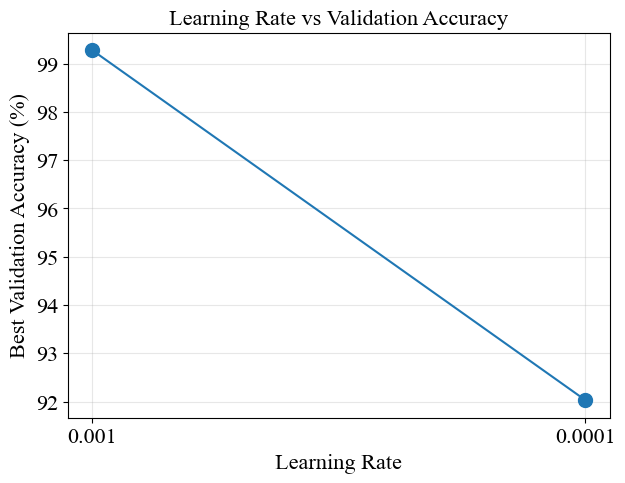

/content/drive/MyDrive/lab_results/plots/plot9_batch_val_acc.eps saved (30.8 KB)


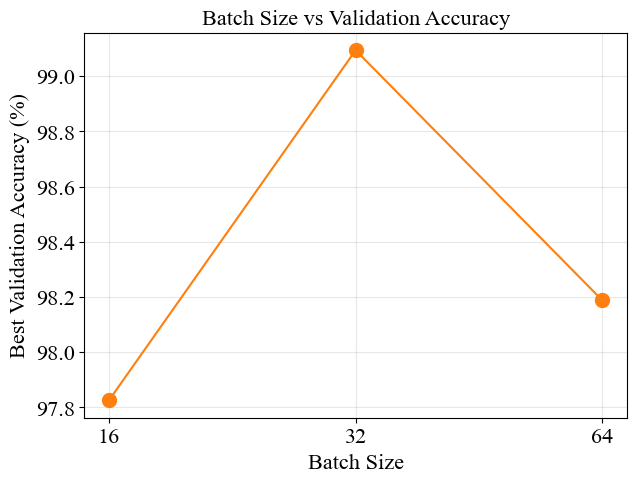

/content/drive/MyDrive/lab_results/plots/plot10_dropout_val_acc.eps saved (27.9 KB)


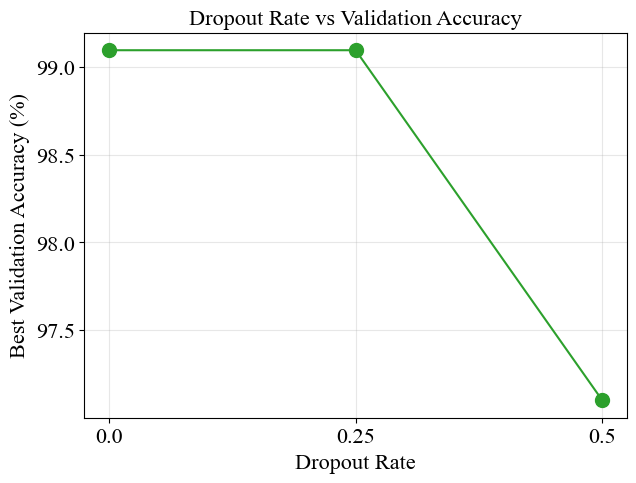

NameError: name 'pd' is not defined

In [ ]:
# ============================================================
# BLOCK 4b — CNN Hyperparameter Tuning: Plotting (reads from Drive)
# ============================================================

lr_vals = [0.001, 0.0001]
batch_vals = [16, 32, 64]
dropout_vals = [0.0, 0.25, 0.5]

lr_histories = {lr: json.load(open(f"{RESULTS_DIR}/histories/hp_lr_{lr}.json")) for lr in lr_vals}
batch_histories = {bs: json.load(open(f"{RESULTS_DIR}/histories/hp_batch_{bs}.json")) for bs in batch_vals}
dropout_histories = {dr: json.load(open(f"{RESULTS_DIR}/histories/hp_dropout_{dr}.json")) for dr in dropout_vals}

# ---- Plot 8: Learning Rate vs Validation Accuracy (best val acc per LR) ----
plt.figure(figsize=(7,5))
best_accs = [max(lr_histories[lr]['val_accuracy'])*100 for lr in lr_vals]
plt.plot([str(lr) for lr in lr_vals], best_accs, marker='o', markersize=10)
plt.xlabel("Learning Rate"); plt.ylabel("Best Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot8_lr_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot8_lr_val_acc")
plt.show()

# ---- Plot 9: Batch Size vs Validation Accuracy ----
plt.figure(figsize=(7,5))
best_accs = [max(batch_histories[bs]['val_accuracy'])*100 for bs in batch_vals]
plt.plot([str(bs) for bs in batch_vals], best_accs, marker='o', markersize=10, color='tab:orange')
plt.xlabel("Batch Size"); plt.ylabel("Best Validation Accuracy (%)")
plt.title("Batch Size vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot9_batch_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot9_batch_val_acc")
plt.show()

# ---- Plot 10: Dropout Rate vs Validation Accuracy ----
plt.figure(figsize=(7,5))
best_accs = [max(dropout_histories[dr]['val_accuracy'])*100 for dr in dropout_vals]
plt.plot([str(dr) for dr in dropout_vals], best_accs, marker='o', markersize=10, color='tab:green')
plt.xlabel("Dropout Rate"); plt.ylabel("Best Validation Accuracy (%)")
plt.title("Dropout Rate vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot10_dropout_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot10_dropout_val_acc")
plt.show()

# ---- Summary table for the report ----
rows = []
for lr in lr_vals:
    rows.append({"Hyperparameter": "Learning Rate", "Value": lr, "Best Val Acc (%)": round(max(lr_histories[lr]['val_accuracy'])*100, 2)})
for bs in batch_vals:
    rows.append({"Hyperparameter": "Batch Size", "Value": bs, "Best Val Acc (%)": round(max(batch_histories[bs]['val_accuracy'])*100, 2)})
for dr in dropout_vals:
    rows.append({"Hyperparameter": "Dropout Rate", "Value": dr, "Best Val Acc (%)": round(max(dropout_histories[dr]['val_accuracy'])*100, 2)})

hp_table = pd.DataFrame(rows)
hp_table.to_csv(f"{RESULTS_DIR}/histories/hyperparam_summary_table.csv", index=False)
print(hp_table)

In [ ]:
# ============================================================
# BLOCK 5a — Transfer Learning (Feature Extraction) vs Fine-Tuning
# ============================================================

def build_model_b5(init='he_normal', dropout_rate=0.3, use_bn_head=True, base_trainable=False, fine_tune_at=None):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    # If fine-tuning, only unfreeze layers from fine_tune_at onward; keep earlier layers frozen
    if base_trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=base_trainable)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=init)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init)(x)
    return models.Model(inputs, outputs)


def run_experiment_b5(name, model, train_ds, val_ds, epochs=8, lr=1e-3):
    hist_path = f"{RESULTS_DIR}/histories/{name}.json"

    if os.path.exists(hist_path):
        print(f"[{name}] history found on Drive — skipping training.")
        with open(hist_path) as f:
            return json.load(f)

    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    hist_dict = history.history
    hist_dict['train_time_sec'] = elapsed
    hist_dict['num_params'] = model.count_params()

    with open(hist_path, "w") as f:
        json.dump(hist_dict, f)

    model.save(f"{RESULTS_DIR}/models/{name}.keras")
    print(f"[{name}] done in {elapsed:.1f}s, final val_acc={hist_dict['val_accuracy'][-1]:.4f}")

    return hist_dict  # NOTE: model NOT deleted here — Case B needs to load its weights


# ---- Pipelines ----
train_ds_b5 = make_pipeline(ds_train_raw, 32, shuffle=True)
val_ds_b5   = make_pipeline(ds_val_raw, 32)

# ---- Case A: Feature Extraction (base frozen) ----
print("\n=== Case A: Feature Extraction ===")
fe_hist_path = f"{RESULTS_DIR}/histories/tl_feature_extraction.json"
fe_model_path = f"{RESULTS_DIR}/models/tl_feature_extraction.keras"

if os.path.exists(fe_hist_path):
    with open(fe_hist_path) as f:
        fe_history = json.load(f)
    print("Case A history found on Drive — skipping training.")
else:
    model_fe = build_model_b5(init='he_normal', dropout_rate=0.3, use_bn_head=True, base_trainable=False)
    fe_history = run_experiment_b5("tl_feature_extraction", model_fe, train_ds_b5, val_ds_b5, epochs=8, lr=1e-3)
    del model_fe
    tf.keras.backend.clear_session()
    gc.collect()

# ---- Case B: Fine-Tuning (load Case A weights, unfreeze top layers, small LR) ----
print("\n=== Case B: Fine-Tuning ===")
ft_hist_path = f"{RESULTS_DIR}/histories/tl_fine_tuning.json"

if os.path.exists(ft_hist_path):
    with open(ft_hist_path) as f:
        ft_history = json.load(f)
    print("Case B history found on Drive — skipping training.")
else:
    # Load the saved feature-extraction model as the fine-tuning starting point
    model_ft = tf.keras.models.load_model(fe_model_path)

    # Unfreeze the MobileNetV2 base (it's nested as a sub-model, typically the 2nd layer: input -> base -> ...)
    base_layer = model_ft.layers[1]
    base_layer.trainable = True

    # Freeze all but the last ~30 layers of the base for partial unfreezing
    fine_tune_at = len(base_layer.layers) - 30
    for layer in base_layer.layers[:fine_tune_at]:
        layer.trainable = False

    ft_history = run_experiment_b5("tl_fine_tuning", model_ft, train_ds_b5, val_ds_b5, epochs=8, lr=1e-5)

    del model_ft
    tf.keras.backend.clear_session()
    gc.collect()

print("\nBlock 5a complete — Feature Extraction and Fine-Tuning histories saved to Drive.")


=== Case A: Feature Extraction ===
Epoch 1/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 276ms/step - accuracy: 0.5764 - loss: 1.6078 - val_accuracy: 0.9203 - val_loss: 0.3612
Epoch 2/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8485 - loss: 0.4717 - val_accuracy: 0.9674 - val_loss: 0.1420
Epoch 3/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8846 - loss: 0.3525 - val_accuracy: 0.9728 - val_loss: 0.0950
Epoch 4/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9162 - loss: 0.2546 - val_accuracy: 0.9783 - val_loss: 0.0749
Epoch 5/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9345 - loss: 0.1999 - val_accuracy: 0.9819 - val_loss: 0.0609
Epoch 6/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9402 - loss: 0.1859 - val_accuracy: 0.9855 - val_loss: 0.0639
Epoch 7/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9501 - loss: 0.1561 - val_accuracy: 0.9873 - val_loss: 0.0617
Epoch 8/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9520 - loss: 0.1

/content/drive/MyDrive/lab_results/plots/plot11_fe_vs_ft_val_acc.eps saved (38.6 KB)


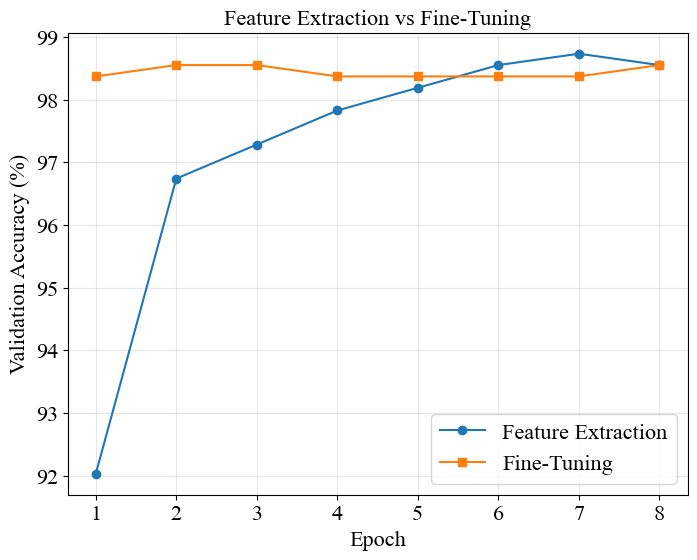

/content/drive/MyDrive/lab_results/plots/plot12_fe_ft_loss.eps saved (42.4 KB)


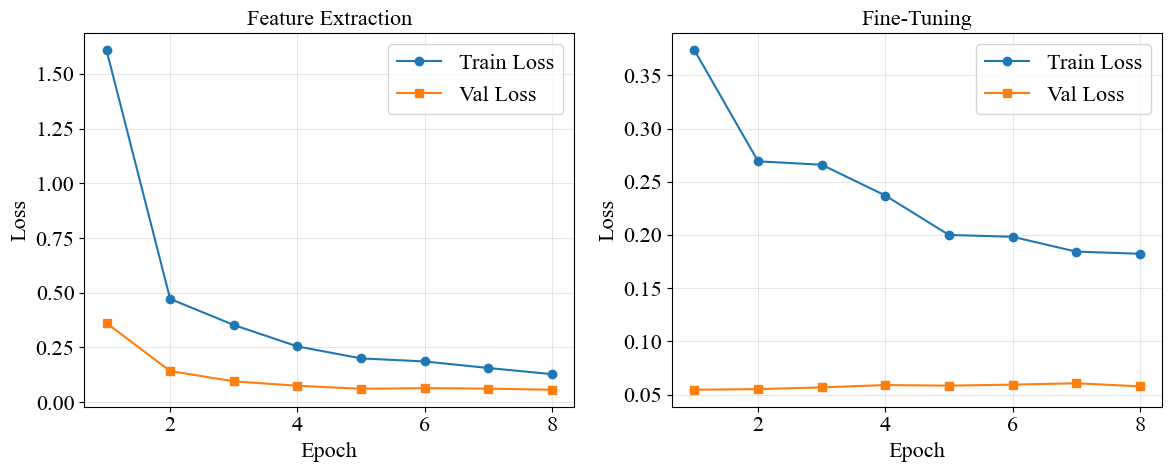

NameError: name 'pd' is not defined

In [ ]:
# ============================================================
# BLOCK 5b — Transfer Learning vs Fine-Tuning: Plotting
# ============================================================

with open(f"{RESULTS_DIR}/histories/tl_feature_extraction.json") as f:
    fe_history = json.load(f)
with open(f"{RESULTS_DIR}/histories/tl_fine_tuning.json") as f:
    ft_history = json.load(f)

# ---- Plot 11: Feature Extraction vs Fine-Tuning (Val Accuracy) ----
plt.figure(figsize=(8,6))
plt.plot(range(1, len(fe_history['val_accuracy'])+1),
         [a*100 for a in fe_history['val_accuracy']], label='Feature Extraction', marker='o')
plt.plot(range(1, len(ft_history['val_accuracy'])+1),
         [a*100 for a in ft_history['val_accuracy']], label='Fine-Tuning', marker='s')
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/plots/plot11_fe_vs_ft_val_acc.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot11_fe_vs_ft_val_acc")
plt.show()

# ---- Plot 12: Training and Validation Loss (before/after fine-tuning) ----
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(range(1, len(fe_history['loss'])+1), fe_history['loss'], label='Train Loss', marker='o')
axes[0].plot(range(1, len(fe_history['val_loss'])+1), fe_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title("Feature Extraction"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(ft_history['loss'])+1), ft_history['loss'], label='Train Loss', marker='o')
axes[1].plot(range(1, len(ft_history['val_loss'])+1), ft_history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title("Fine-Tuning"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plots/plot12_fe_ft_loss.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot12_fe_ft_loss")
plt.show()

# ---- Summary table ----
summary = pd.DataFrame([
    {"Case": "Feature Extraction", "Best Val Acc (%)": round(max(fe_history['val_accuracy'])*100, 2),
     "Final Loss": round(fe_history['loss'][-1], 4), "Time (s)": round(fe_history['train_time_sec'], 1)},
    {"Case": "Fine-Tuning", "Best Val Acc (%)": round(max(ft_history['val_accuracy'])*100, 2),
     "Final Loss": round(ft_history['loss'][-1], 4), "Time (s)": round(ft_history['train_time_sec'], 1)},
])
summary.to_csv(f"{RESULTS_DIR}/histories/tl_summary_table.csv", index=False)
print(summary)

In [ ]:
# ============================================================
# BLOCK 6a — 5-Fold Cross-Validation: Training
# Select 3-4 promising configs based on Blocks 1-5 results, then CV each
# ============================================================

from sklearn.model_selection import KFold

# ---- Materialize the full training pool (train+val, NOT test) into NumPy once ----
# This is a one-time cost per session; ~3128 images at 224x224x3 float32 ≈ 1.9GB
CV_POOL_CACHE = f"{RESULTS_DIR}/cv/cv_pool.npz"

if os.path.exists(CV_POOL_CACHE):
    print("Loading cached CV pool from Drive...")
    data = np.load(CV_POOL_CACHE)
    X_pool, y_pool = data['X'], data['y']
else:
    print("Materializing CV pool (train+val) into memory — one-time cost...")
    pool_ds = ds_train_raw.concatenate(ds_val_raw).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    X_list, y_list = [], []
    for img, label in pool_ds.batch(64):
        X_list.append(img.numpy())
        y_list.append(label.numpy())
    X_pool = np.concatenate(X_list, axis=0)
    y_pool = np.concatenate(y_list, axis=0)
    np.savez(CV_POOL_CACHE, X=X_pool, y=y_pool)
    print(f"Cached CV pool to Drive: {X_pool.shape}")

print(f"CV pool size: {len(X_pool)} samples")

def build_model_b6(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True, optimizer='adam', lr=1e-3):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=init, kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init, kernel_regularizer=reg)(x)
    model = models.Model(inputs, outputs)

    opt = optimizers.SGD(learning_rate=lr, momentum=0.9) if optimizer == 'momentum' else optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ---- 3-4 candidate configs, selected using Blocks 1-5 winners ----
# EDIT THESE based on your actual best results from earlier blocks before running
cv_configs = {
    "C1_baseline":        dict(init='he_normal', dropout_rate=0.3, l2_lambda=0.0,  use_bn_head=True,  optimizer='adam',     lr=1e-3),
    "C2_best_init_reg":   dict(init='he_normal', dropout_rate=0.5, l2_lambda=0.0,  use_bn_head=True,  optimizer='adam',     lr=1e-3),
    "C3_best_optimizer":  dict(init='he_normal', dropout_rate=0.3, l2_lambda=0.0,  use_bn_head=True,  optimizer='momentum', lr=1e-3),
    "C4_best_hp":         dict(init='he_normal', dropout_rate=0.25, l2_lambda=1e-4, use_bn_head=True, optimizer='adam',     lr=1e-4),
}

CV_RESULTS_CSV = f"{RESULTS_DIR}/cv/cv_fold_results.csv"
CV_EPOCHS = 6  # kept modest — this is 20 total training runs

# ---- Load existing results if resuming ----
if os.path.exists(CV_RESULTS_CSV):
    cv_results_df = pd.read_csv(CV_RESULTS_CSV)
else:
    cv_results_df = pd.DataFrame(columns=["config", "fold", "val_accuracy", "val_loss", "train_time_sec"])

def fold_already_done(config_name, fold_idx):
    return not cv_results_df[(cv_results_df.config == config_name) & (cv_results_df.fold == fold_idx)].empty

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(kf.split(X_pool))

for config_name, cfg in cv_configs.items():
    print(f"\n========== Config: {config_name} ==========")
    for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
        if fold_already_done(config_name, fold_idx):
            print(f"[{config_name} fold {fold_idx}] already done — skipping.")
            continue

        print(f"\n--- {config_name} | Fold {fold_idx+1}/5 ---")
        X_train_fold, y_train_fold = X_pool[train_idx], y_pool[train_idx]
        X_val_fold, y_val_fold = X_pool[val_idx], y_pool[val_idx]

        train_ds_fold = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold)) \
                            .shuffle(1000, seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE)
        val_ds_fold = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold)) \
                            .batch(32).prefetch(tf.data.AUTOTUNE)

        model = build_model_b6(**cfg)

        start = time.time()
        history = model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=CV_EPOCHS, verbose=1)
        elapsed = time.time() - start

        final_val_acc = history.history['val_accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]

        # ---- Append this fold's result immediately (crash-safe) ----
        new_row = pd.DataFrame([{
            "config": config_name, "fold": fold_idx,
            "val_accuracy": final_val_acc, "val_loss": final_val_loss,
            "train_time_sec": elapsed
        }])
        cv_results_df = pd.concat([cv_results_df, new_row], ignore_index=True)
        cv_results_df.to_csv(CV_RESULTS_CSV, index=False)

        print(f"[{config_name} fold {fold_idx}] val_acc={final_val_acc:.4f}, saved to CSV.")

        del model, history, train_ds_fold, val_ds_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold
        tf.keras.backend.clear_session()
        gc.collect()

print("\nBlock 6a complete — all fold results saved incrementally to Drive.")

Loading cached CV pool from Drive...
CV pool size: 3680 samples

========== Config: C1_baseline ==========
[C1_baseline fold 0] already done — skipping.
[C1_baseline fold 1] already done — skipping.
[C1_baseline fold 2] already done — skipping.
[C1_baseline fold 3] already done — skipping.
[C1_baseline fold 4] already done — skipping.

========== Config: C2_best_init_reg ==========
[C2_best_init_reg fold 0] already done — skipping.
[C2_best_init_reg fold 1] already done — skipping.
[C2_best_init_reg fold 2] already done — skipping.
[C2_best_init_reg fold 3] already done — skipping.
[C2_best_init_reg fold 4] already done — skipping.

========== Config: C3_best_optimizer ==========
[C3_best_optimizer fold 0] already done — skipping.

--- C3_best_optimizer | Fold 2/5 ---
Epoch 1/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 92ms/step - accuracy: 0.2300 - loss: 3.3131 - val_accuracy: 0.6984 - val_loss: 1.6480
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6090 - loss: 1.3542 - val_accu

       Configuration     F1     F2     F3     F4     F5     Mean ± SD
0        C1_baseline  92.26  91.30  93.21  93.07  90.76  92.12 ± 0.96
1   C2_best_init_reg  91.98  90.62  92.53  92.12  90.22  91.49 ± 0.90
2  C3_best_optimizer  90.49  88.72  90.90  88.99  87.91  89.40 ± 1.12
3         C4_best_hp  88.04  86.82  89.40  86.28  86.96  87.50 ± 1.11


/content/drive/MyDrive/lab_results/plots/plot13_cv_accuracy.eps saved (37.3 KB)


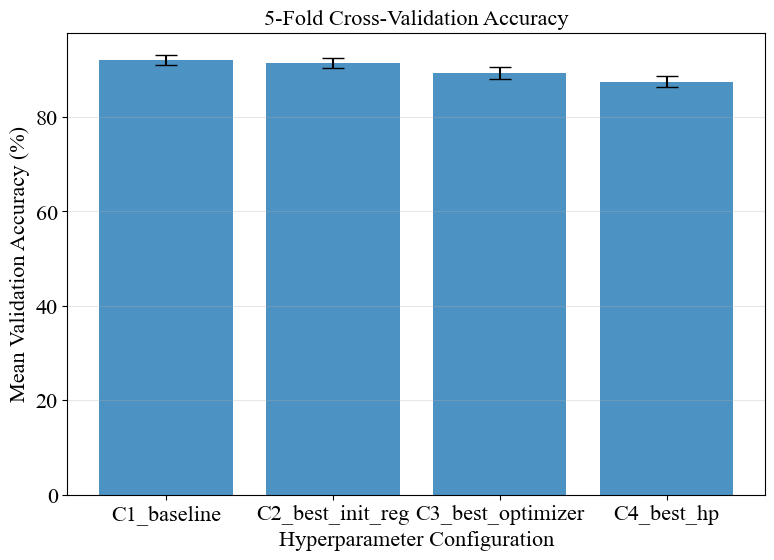


Best configuration by mean CV accuracy: C1_baseline
Mean: 92.12%, SD: 1.07%


In [ ]:
# ============================================================
# BLOCK 6b — 5-Fold Cross-Validation: Plotting (reads from Drive)
# ============================================================

cv_results_df = pd.read_csv(f"{RESULTS_DIR}/cv/cv_fold_results.csv")

summary_rows = []
for config_name in cv_results_df['config'].unique():
    sub = cv_results_df[cv_results_df.config == config_name].sort_values('fold')
    accs = sub['val_accuracy'].values * 100
    mean_acc = accs.mean()
    std_acc = accs.std()
    row = {"Configuration": config_name}
    for i, a in enumerate(accs):
        row[f"F{i+1}"] = round(a, 2)
    row["Mean ± SD"] = f"{mean_acc:.2f} ± {std_acc:.2f}"
    summary_rows.append(row)

cv_summary_table = pd.DataFrame(summary_rows)
cv_summary_table.to_csv(f"{RESULTS_DIR}/cv/cv_summary_table.csv", index=False)
print(cv_summary_table)

# ---- Plot 13: 5-Fold CV Accuracy with error bars ----
configs = cv_results_df['config'].unique()
means = [cv_results_df[cv_results_df.config == c]['val_accuracy'].mean() * 100 for c in configs]
stds  = [cv_results_df[cv_results_df.config == c]['val_accuracy'].std() * 100 for c in configs]

plt.figure(figsize=(9,6))
plt.bar(configs, means, yerr=stds, capsize=8, color='tab:blue', alpha=0.8)
plt.xlabel("Hyperparameter Configuration"); plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid(alpha=0.3, axis='y')
plt.savefig(f"{RESULTS_DIR}/plots/plot13_cv_accuracy.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot13_cv_accuracy")
plt.show()

# ---- Identify best config for Block 8 (final model) ----
best_config = configs[np.argmax(means)]
print(f"\nBest configuration by mean CV accuracy: {best_config}")
print(f"Mean: {max(means):.2f}%, SD: {stds[np.argmax(means)]:.2f}%")

In [ ]:
# ============================================================
# BLOCK 7a — Additional Exercise: 2 new configs, 5-fold CV
# ============================================================


from sklearn.model_selection import KFold

# ---- Load the CV pool (already cached from Block 6a) ----
CV_POOL_CACHE = f"{RESULTS_DIR}/cv/cv_pool.npz"
data = np.load(CV_POOL_CACHE)
X_pool, y_pool = data['X'], data['y']
print(f"CV pool size: {len(X_pool)} samples")

def build_model_b7(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True,
                    optimizer='adam', lr=1e-3, base_trainable=False, fine_tune_at=None):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable
    if base_trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=base_trainable)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=init, kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init, kernel_regularizer=reg)(x)
    model = models.Model(inputs, outputs)

    opt = optimizers.SGD(learning_rate=lr, momentum=0.9) if optimizer == 'momentum' else optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ---- 2 new candidate configs — different combos of LR, dropout, batch size, fine-tuning ----
extra_configs = {
    "E1_light_finetune": dict(init='he_normal', dropout_rate=0.4, l2_lambda=0.0, use_bn_head=True,
                               optimizer='adam', lr=5e-4, base_trainable=True, fine_tune_at=140,
                               batch_size=16),
    "E2_wide_batch":     dict(init='he_normal', dropout_rate=0.2, l2_lambda=1e-5, use_bn_head=True,
                               optimizer='adam', lr=1e-3, base_trainable=False, fine_tune_at=None,
                               batch_size=64),
}

CV_RESULTS_CSV = f"{RESULTS_DIR}/cv/cv_fold_results.csv"  # append to same CSV as Block 6
cv_results_df = pd.read_csv(CV_RESULTS_CSV)

def fold_already_done(config_name, fold_idx):
    return not cv_results_df[(cv_results_df.config == config_name) & (cv_results_df.fold == fold_idx)].empty

CV_EPOCHS = 6
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(kf.split(X_pool))

for config_name, cfg in extra_configs.items():
    batch_size = cfg.pop('batch_size')
    print(f"\n========== Config: {config_name} ==========")

    for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
        if fold_already_done(config_name, fold_idx):
            print(f"[{config_name} fold {fold_idx}] already done — skipping.")
            continue

        print(f"\n--- {config_name} | Fold {fold_idx+1}/5 ---")
        X_train_fold, y_train_fold = X_pool[train_idx], y_pool[train_idx]
        X_val_fold, y_val_fold = X_pool[val_idx], y_pool[val_idx]

        train_ds_fold = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold)) \
                            .shuffle(1000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        val_ds_fold = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold)) \
                            .batch(batch_size).prefetch(tf.data.AUTOTUNE)

        model = build_model_b7(**cfg)

        start = time.time()
        history = model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=CV_EPOCHS, verbose=1)
        elapsed = time.time() - start

        final_val_acc = history.history['val_accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]

        # ---- Also save per-epoch history for optional epoch-wise plotting ----
        fold_hist_path = f"{RESULTS_DIR}/cv/hist_{config_name}_fold{fold_idx}.json"
        with open(fold_hist_path, "w") as f:
            json.dump(history.history, f)

        new_row = pd.DataFrame([{
            "config": config_name, "fold": fold_idx,
            "val_accuracy": final_val_acc, "val_loss": final_val_loss,
            "train_time_sec": elapsed
        }])
        cv_results_df = pd.concat([cv_results_df, new_row], ignore_index=True)
        cv_results_df.to_csv(CV_RESULTS_CSV, index=False)

        print(f"[{config_name} fold {fold_idx}] val_acc={final_val_acc:.4f}, saved to CSV.")

        del model, history, train_ds_fold, val_ds_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold
        tf.keras.backend.clear_session()
        gc.collect()

    cfg['batch_size'] = batch_size  # restore for record-keeping, harmless

print("\nBlock 7a complete — E1 and E2 fold results appended to Drive.")

CV pool size: 3680 samples

========== Config: E1_light_finetune ==========
[E1_light_finetune fold 0] already done — skipping.

--- E1_light_finetune | Fold 2/5 ---
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.5496 - loss: 1.8489 - val_accuracy: 0.7622 - val_loss: 1.0704
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7785 - loss: 0.7595 - val_accuracy: 0.7595 - val_loss: 1.6682
Epoch 3/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8322 - loss: 0.5557 - val_accuracy: 0.7514 - val_loss: 1.9291
Epoch 4/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8791 - loss: 0.4248 - val_accuracy: 0.7405 - val_loss: 2.0449
Epoch 5/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9083 - loss: 0.3308 - val_accuracy: 0.7609 - val_loss: 1.3431
Epoch 6/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9056 - loss: 0.3043 - val_accuracy: 0.8438 - val_loss: 0.8528
[E1_light_finetune fold 1] val_acc=0.8438, saved to CSV.

--- E1_

       Configuration     F1     F2     F3     F4     F5     Mean ± SD
0        C1_baseline  92.26  91.30  93.21  93.07  90.76  92.12 ± 0.96
1  E1_light_finetune  81.93  84.38  79.08  78.80  84.92  81.82 ± 2.56
2      E2_wide_batch  92.39  89.67  92.26  91.44  91.17  91.39 ± 0.97


/content/drive/MyDrive/lab_results/plots/plot16_additional_exercise.eps saved (36.5 KB)


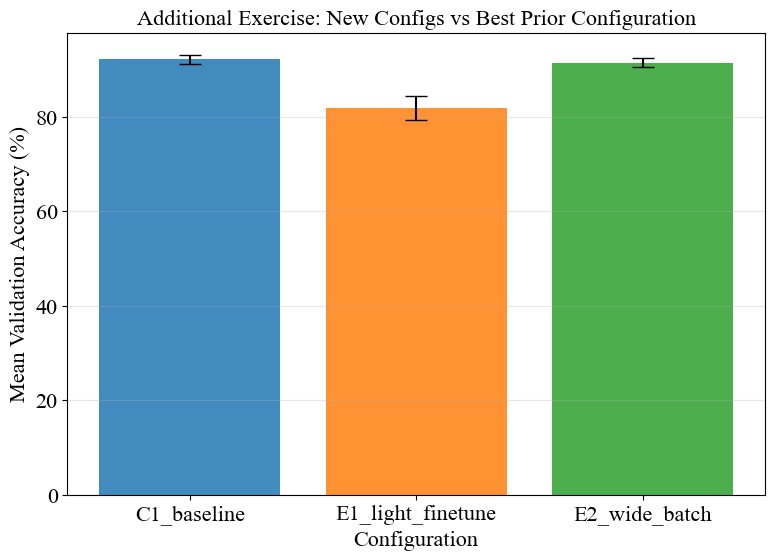


Best overall configuration: C1_baseline
Mean: 92.12%, SD: 0.96%

Computational cost (mean time/fold):
  C1_baseline: 45.1s
  E1_light_finetune: 56.4s
  E2_wide_batch: 50.5s


In [ ]:
# ============================================================
# BLOCK 7b — Additional Exercise: Plotting (reads from Drive)
# ============================================================

cv_results_df = pd.read_csv(f"{RESULTS_DIR}/cv/cv_fold_results.csv")

# ---- Compare E1, E2 against the Block 6 winner (C1_baseline) ----
compare_configs = ["C1_baseline", "E1_light_finetune", "E2_wide_batch"]

summary_rows = []
for config_name in compare_configs:
    sub = cv_results_df[cv_results_df.config == config_name].sort_values('fold')
    accs = sub['val_accuracy'].values * 100
    mean_acc = accs.mean()
    std_acc = accs.std(ddof=0)  # population SD, matching lab spec
    row = {"Configuration": config_name}
    for i, a in enumerate(accs):
        row[f"F{i+1}"] = round(a, 2)
    row["Mean ± SD"] = f"{mean_acc:.2f} ± {std_acc:.2f}"
    summary_rows.append(row)

extra_summary_table = pd.DataFrame(summary_rows)
extra_summary_table.to_csv(f"{RESULTS_DIR}/cv/additional_exercise_summary_table.csv", index=False)
print(extra_summary_table)

# ---- Bar chart: baseline vs new configs ----
means = [cv_results_df[cv_results_df.config == c]['val_accuracy'].mean() * 100 for c in compare_configs]
stds  = [cv_results_df[cv_results_df.config == c]['val_accuracy'].std(ddof=0) * 100 for c in compare_configs]

plt.figure(figsize=(9,6))
plt.bar(compare_configs, means, yerr=stds, capsize=8, color=['tab:blue','tab:orange','tab:green'], alpha=0.85)
plt.xlabel("Configuration"); plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Additional Exercise: New Configs vs Best Prior Configuration")
plt.grid(alpha=0.3, axis='y')
plt.savefig(f"{RESULTS_DIR}/plots/plot16_additional_exercise.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot16_additional_exercise")
plt.show()

# ---- Verdict ----
best_overall = compare_configs[np.argmax(means)]
print(f"\nBest overall configuration: {best_overall}")
print(f"Mean: {max(means):.2f}%, SD: {stds[np.argmax(means)]:.2f}%")
print(f"\nComputational cost (mean time/fold):")
for c in compare_configs:
    avg_time = cv_results_df[cv_results_df.config == c]['train_time_sec'].mean()
    print(f"  {c}: {avg_time:.1f}s")

In [ ]:
# ============================================================
# BLOCK 8a — Final Model: Retrain + Test Set Evaluation
# Winner from Block 6/7 CV comparison: C1_baseline (92.12% ± 0.96%, fastest, best overall)
# ============================================================

BEST_CONFIG_NAME = "C1_baseline"
best_cfg = dict(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True,
                 optimizer='adam', lr=1e-3, base_trainable=False, fine_tune_at=None)
batch_size = 32

print(f"Retraining final model using config: {BEST_CONFIG_NAME}")
print(best_cfg)

def build_model_b8(init='he_normal', dropout_rate=0.3, l2_lambda=0.0, use_bn_head=True,
                    optimizer='adam', lr=1e-3, base_trainable=False, fine_tune_at=None):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable
    if base_trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=base_trainable)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=init, kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init, kernel_regularizer=reg)(x)
    model = models.Model(inputs, outputs)

    opt = optimizers.SGD(learning_rate=lr, momentum=0.9) if optimizer == 'momentum' else optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

FINAL_MODEL_PATH = f"{RESULTS_DIR}/models/final_model_{BEST_CONFIG_NAME}.keras"
FINAL_HIST_PATH = f"{RESULTS_DIR}/histories/final_model_{BEST_CONFIG_NAME}.json"

if os.path.exists(FINAL_HIST_PATH) and os.path.exists(FINAL_MODEL_PATH):
    print("Final model already trained and saved — loading from Drive.")
    with open(FINAL_HIST_PATH) as f:
        final_history = json.load(f)
    final_model = tf.keras.models.load_model(FINAL_MODEL_PATH)
else:
    CV_POOL_CACHE = f"{RESULTS_DIR}/cv/cv_pool.npz"
    data = np.load(CV_POOL_CACHE)
    X_full, y_full = data['X'], data['y']

    train_ds_final = tf.data.Dataset.from_tensor_slices((X_full, y_full)) \
                        .shuffle(1000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    final_model = build_model_b8(**best_cfg)

    start = time.time()
    history = final_model.fit(train_ds_final, epochs=12, verbose=1)
    elapsed = time.time() - start

    final_history = history.history
    final_history['train_time_sec'] = elapsed
    final_history['num_params'] = final_model.count_params()

    with open(FINAL_HIST_PATH, "w") as f:
        json.dump(final_history, f)
    final_model.save(FINAL_MODEL_PATH)

    print(f"Final model trained in {elapsed:.1f}s")
    del train_ds_final, X_full, y_full
    gc.collect()



Retraining final model using config: C1_baseline
{'init': 'he_normal', 'dropout_rate': 0.3, 'l2_lambda': 0.0, 'use_bn_head': True, 'optimizer': 'adam', 'lr': 0.001, 'base_trainable': False, 'fine_tune_at': None}
Epoch 1/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.6190 - loss: 1.4923
Epoch 2/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8576 - loss: 0.4446
Epoch 3/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8951 - loss: 0.3152
Epoch 4/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9187 - loss: 0.2499
Epoch 5/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9375 - loss: 0.1856
Epoch 6/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9465 - loss: 0.1558
Epoch 7/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9543 - loss: 0.1423
Epoch 8/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9611 - loss: 0.1172
Epoch 9/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9622 - loss: 0.1094
Epoc

NameError: name 'ds_test_pipeline' is not defined

/content/drive/MyDrive/lab_results/plots/plot14_confusion_matrix.pdf saved (EPS was 311316.9 KB)


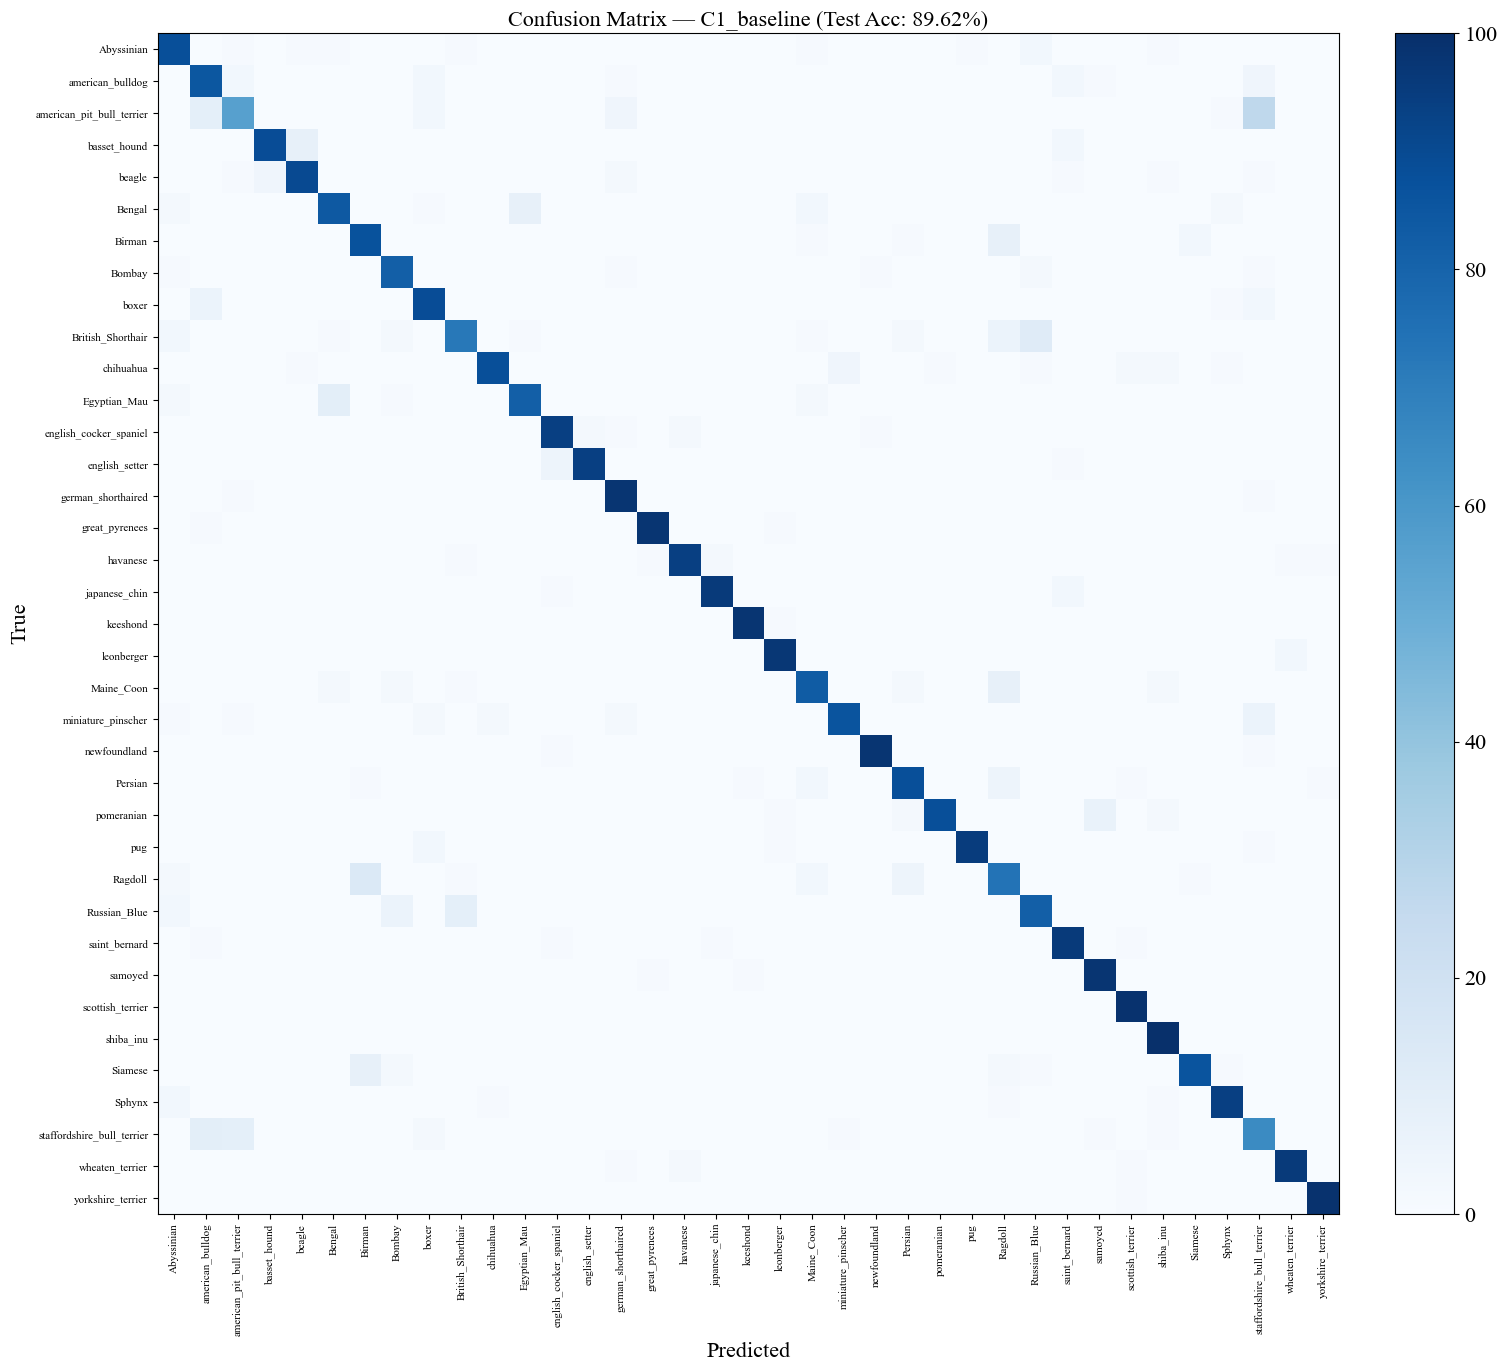

Best classified classes:
  shiba_inu: 100.0%
  scottish_terrier: 100.0%
  yorkshire_terrier: 99.0%
  keeshond: 99.0%
  samoyed: 98.0%

Worst classified classes:
  american_pit_bull_terrier: 56.0%
  British_Shorthair: 72.0%
  staffordshire_bull_terrier: 73.0%
  Ragdoll: 74.0%
  Russian_Blue: 82.0%

Most frequently confused class pairs:
  True: american_pit_bull_terrier → Predicted: staffordshire_bull_terrier (27 times)
  True: Ragdoll → Predicted: Birman (14 times)
  True: British_Shorthair → Predicted: Russian_Blue (12 times)
  True: staffordshire_bull_terrier → Predicted: american_bulldog (10 times)
  True: Egyptian_Mau → Predicted: Bengal (10 times)


NameError: name 'ds_test_pipeline' is not defined

In [ ]:
# ============================================================
# BLOCK 8b — Plot 14 (Confusion Matrix) + Optional Plot 15 (Misclassified Images)
# ============================================================

data = np.load(f"{RESULTS_DIR}/cv/final_test_predictions.npz")
y_true, y_pred, cm = data['y_true'], data['y_pred'], data['cm']

with open(f"{RESULTS_DIR}/cv/final_metrics.json") as f:
    final_metrics = json.load(f)

class_names = ds_info.features['label'].names  # breed names from tfds metadata

# ---- Plot 14: Confusion Matrix ----
plt.figure(figsize=(16, 14))
plt.imshow(cm, cmap='Blues')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(class_names)), class_names, rotation=90, fontsize=8)
plt.yticks(range(len(class_names)), class_names, fontsize=8)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix — {final_metrics['config']} (Test Acc: {final_metrics['test_accuracy']:.2f}%)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plots/plot14_confusion_matrix.png", dpi=300, bbox_inches='tight')
save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot14_confusion_matrix")
plt.show()

# ---- Identify best-classified and most-confused class pairs ----
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes = np.argsort(per_class_acc)[-5:][::-1]
worst_classes = np.argsort(per_class_acc)[:5]

print("Best classified classes:")
for idx in best_classes:
    print(f"  {class_names[idx]}: {per_class_acc[idx]*100:.1f}%")

print("\nWorst classified classes:")
for idx in worst_classes:
    print(f"  {class_names[idx]}: {per_class_acc[idx]*100:.1f}%")

# ---- Most confused pairs (off-diagonal, top 5) ----
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
top_confusions = np.dstack(np.unravel_index(np.argsort(-cm_offdiag.ravel())[:5], cm_offdiag.shape))[0]

print("\nMost frequently confused class pairs:")
for true_idx, pred_idx in top_confusions:
    count = cm[true_idx, pred_idx]
    if count > 0:
        print(f"  True: {class_names[true_idx]} → Predicted: {class_names[pred_idx]} ({count} times)")

# ---- Optional Plot 15: Misclassified images ----
misclassified_idx = np.where(y_true != y_pred)[0][:9]  # first 9 for a 3x3 grid

if len(misclassified_idx) > 0:
    images_list = []
    for imgs, _ in ds_test_pipeline:
        images_list.append(imgs.numpy())
    all_test_images = np.concatenate(images_list, axis=0)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ax, idx in zip(axes.flat, misclassified_idx):
        img = (all_test_images[idx] + 1) / 2  # undo mobilenet_v2 preprocess_input [-1,1] -> [0,1]
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
        ax.axis('off')
    plt.suptitle("Misclassified Test Images", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/plots/plot15_misclassified.png", dpi=300, bbox_inches='tight')
    save_eps_or_pdf(f"{RESULTS_DIR}/plots/plot15_misclassified")
    plt.show()

    del images_list, all_test_images
    gc.collect()
else:
    print("No misclassified samples found — skipping Plot 15.")

In [ ]:
# ---- Rebuild test pipeline if missing (e.g. fresh session after disconnect) ----
if 'ds_test_pipeline' not in dir():
    print("ds_test_pipeline not found — rebuilding from tfds...")
    (_, ds_test), _ = tfds.load(
        "oxford_iiit_pet",
        split=["train", "test"],
        with_info=True,
        as_supervised=True,
    )
    def preprocess(image, label):
        image = tf.image.resize(image, IMG_SIZE)
        image = preprocess_input(image)
        return image, label
    ds_test_pipeline = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().batch(32).prefetch(tf.data.AUTOTUNE)
    print("ds_test_pipeline rebuilt.")

ds_test_pipeline not found — rebuilding from tfds...
ds_test_pipeline rebuilt.


In [ ]:
# ---- Evaluate ONCE on the untouched test set ----
print("\n=== Evaluating on TEST SET (first and only touch) ===")
test_loss, test_acc = final_model.evaluate(ds_test_pipeline, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%  |  Test Loss: {test_loss:.4f}")

# ---- Predictions for precision/recall/F1/confusion matrix ----
y_true, y_pred = [], []
for images, labels in ds_test_pipeline:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_true, y_pred)

np.savez(f"{RESULTS_DIR}/cv/final_test_predictions.npz", y_true=y_true, y_pred=y_pred, cm=cm)

cv_results_df = pd.read_csv(f"{RESULTS_DIR}/cv/cv_fold_results.csv")

final_metrics = {
    "config": BEST_CONFIG_NAME,
    "mean_cv_accuracy": float(cv_results_df[cv_results_df.config == BEST_CONFIG_NAME]['val_accuracy'].mean() * 100),
    "cv_sd": float(cv_results_df[cv_results_df.config == BEST_CONFIG_NAME]['val_accuracy'].std(ddof=0) * 100),
    "test_accuracy": float(test_acc * 100),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "training_time_sec": final_history.get('train_time_sec'),
    "num_params": final_history.get('num_params'),
}
with open(f"{RESULTS_DIR}/cv/final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\nFinal metrics:")
for k, v in final_metrics.items():
    print(f"  {k}: {v}")

del final_model
tf.keras.backend.clear_session()
gc.collect()


=== Evaluating on TEST SET (first and only touch) ===
115/115 ━━━━━━━━━━━━━━━━━━━━ 29s 211ms/step - accuracy: 0.8962 - loss: 0.4172
Test Accuracy: 89.62%  |  Test Loss: 0.4172

Final metrics:
  config: C1_baseline
  mean_cv_accuracy: 92.1195650100708
  cv_sd: 0.9607417950799075
  test_accuracy: 89.61569666862488
  precision: 0.897766946302968
  recall: 0.8957936258857973
  f1_score: 0.8952082230838477
  training_time_sec: 73.6272988319397
  num_params: 2431845


0

In [4]:
# ============================================================
# OVERALL RESULTS — Test Accuracy + SD for Saved Models
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

# ------------------------------------------------------------
# Rebuild test pipeline if necessary
# ------------------------------------------------------------
if 'ds_test_pipeline' not in dir():
    print("Rebuilding test pipeline...")

    (_, ds_test), _ = tfds.load(
        "oxford_iiit_pet",
        split=["train", "test"],
        with_info=True,
        as_supervised=True,
    )

    ds_test_pipeline = (
        ds_test
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .batch(32)
        .prefetch(tf.data.AUTOTUNE)
    )

# ------------------------------------------------------------
# Models corresponding to the overall-results table
# ------------------------------------------------------------
model_files = {
    "Baseline": "final_model_C1_baseline.keras",

    # Best initialization
    "Best Initialization": "init_he.keras",

    # Best regularization
    "Best Regularization": "reg_l2_reg.keras",

    # Best optimizer
    "Best Optimizer": "optim_adam.keras",

    # Best hyperparameters
    # Change this if your actual best HP model was different
    "Best Hyperparameters": "hp_lr_0.0001.keras",

    # Fine-tuned model
    "Fine-Tuned Model": "tl_fine_tuning.keras",
}

# ------------------------------------------------------------
# Existing CV results — used to obtain SD where available
# ------------------------------------------------------------
cv_path = f"{RESULTS_DIR}/cv/cv_fold_results.csv"

if os.path.exists(cv_path):
    cv_results = pd.read_csv(cv_path)
else:
    cv_results = pd.DataFrame()

# Map table names to CV configuration names
cv_mapping = {
    "Baseline": "C1_baseline",
    "Best Initialization": None,
    "Best Regularization": None,
    "Best Optimizer": None,
    "Best Hyperparameters": None,
    "Fine-Tuned Model": None,
}

# ------------------------------------------------------------
# Evaluate every saved model on TEST SET
# ------------------------------------------------------------
results = []

for name, filename in model_files.items():

    model_path = f"{RESULTS_DIR}/models/{filename}"

    print(f"\n=== {name} ===")
    print(f"Loading: {model_path}")

    if not os.path.exists(model_path):
        print("Model not found!")
        results.append({
            "Configuration": name,
            "Test Accuracy": "N/A",
            "SD": "N/A"
        })
        continue

    model = tf.keras.models.load_model(model_path)

    test_loss, test_acc = model.evaluate(
        ds_test_pipeline,
        verbose=0
    )

    # --------------------------------------------------------
    # SD from 5-fold CV, if this model has a CV configuration
    # --------------------------------------------------------
    cv_name = cv_mapping.get(name)

    if cv_name is not None and not cv_results.empty:
        sub = cv_results[cv_results["config"] == cv_name]

        if len(sub) > 0:
            sd = sub["val_accuracy"].std(ddof=0) * 100
        else:
            sd = np.nan
    else:
        sd = np.nan

    results.append({
        "Configuration": name,
        "Test Accuracy": test_acc * 100,
        "SD": sd
    })

    print(f"Test Accuracy : {test_acc * 100:.2f}%")
    print(f"SD            : {sd:.2f}%" if not np.isnan(sd) else "SD            : N/A")

    del model
    tf.keras.backend.clear_session()
    gc.collect()

# ------------------------------------------------------------
# Display final table
# ------------------------------------------------------------
overall_results = pd.DataFrame(results)

overall_results["Test Accuracy"] = overall_results["Test Accuracy"].apply(
    lambda x: f"{x:.2f}%" if isinstance(x, (int, float, np.number)) else x
)

overall_results["SD"] = overall_results["SD"].apply(
    lambda x: f"{x:.2f}%" if isinstance(x, (int, float, np.number)) else x
)

print("\n" + "=" * 60)
print("OVERALL RESULTS")
print("=" * 60)
print(overall_results.to_string(index=False))

Rebuilding test pipeline...

=== Baseline ===
Loading: /content/drive/MyDrive/lab_results/models/final_model_C1_baseline.keras
Test Accuracy : 89.62%
SD            : 0.96%

=== Best Initialization ===
Loading: /content/drive/MyDrive/lab_results/models/init_he.keras
Test Accuracy : 89.53%
SD            : N/A

=== Best Regularization ===
Loading: /content/drive/MyDrive/lab_results/models/reg_l2_reg.keras
Test Accuracy : 90.13%
SD            : N/A

=== Best Optimizer ===
Loading: /content/drive/MyDrive/lab_results/models/optim_adam.keras
Test Accuracy : 89.15%
SD            : N/A

=== Best Hyperparameters ===
Loading: /content/drive/MyDrive/lab_results/models/hp_lr_0.0001.keras
Test Accuracy : 86.21%
SD            : N/A

=== Fine-Tuned Model ===
Loading: /content/drive/MyDrive/lab_results/models/tl_fine_tuning.keras
Test Accuracy : 89.81%
SD            : N/A

OVERALL RESULTS
       Configuration Test Accuracy    SD
            Baseline        89.62% 0.96%
 Best Initialization        89.53